# **Instalasi Library Tambahan**

Proses instalasi beberapa library tambahan yang diperlukan
untuk membantu analisis data spasial dan visualisasi peta.

In [138]:
!pip install folium

In [139]:
!pip install contextily

# **Import Library Utama**

In [140]:
import geopandas as gpd
import contextily as ctx
import folium
from folium.plugins import HeatMap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# **Loading Dataset**

In [141]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [142]:
import pandas as pd

# Load CSV yang sudah didownload
df = pd.read_csv("/content/gdrive/MyDrive/Machine Learning/Pertemuan11/Tugas/data/indonesia_province.csv")
df.head()

,provinsi,jml_penduduk,latitude,longitude
0,IRIAN JAYA TIMUR,1416690,-5.124371,139.399516
1,NUSATENGGARA BARAT,4500212,-8.606151,117.526167
2,GORONTALO,1040164,0.690232,122.376941
3,SULAWESI TENGGARA,2232586,-4.118700,122.076699
4,DAERAH ISTIMEWA YOGYAKARTA,3457491,-7.891517,110.448242


### **Menampilkan informasi detail dengan df.info()**

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   provinsi      32 non-null     object 
 1   jml_penduduk  32 non-null     int64  
 2   latitude      32 non-null     float64
 3   longitude     32 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.1+ KB


### **Cek Missing Value dan Data Duplikat**

In [144]:
df.isnull().sum()

,0
provinsi,0
jml_penduduk,0
latitude,0
longitude,0


In [145]:
df.duplicated().sum()

np.int64(0)

### **Menampilkan statistika deskriptif dari dataset**

In [146]:
df.describe()

,jml_penduduk,latitude,longitude
count,3.200000e+01,32.000000,32.000000
mean,7.337610e+06,-3.226684,114.411169
std,1.042569e+07,3.534267,11.218013
min,7.604220e+05,-9.252542,96.909539
25%,2.087946e+06,-6.264491,105.835368
50%,3.758686e+06,-3.197732,113.074701
75%,7.489897e+06,-0.674138,122.105700
max,4.305373e+07,4.225394,139.399516


# **Exploratory Data Analysis (EDA)**

### **Visualisasi Heatmap Sebaran Jumlah Penduduk**

In [147]:
import folium
from folium.plugins import HeatMap

# Buat peta dasar Indonesia
peta_indonesia = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Buat list data [lat, long, value] untuk heatmap
# Ganti 'latitude', 'longitude', 'jml_penduduk' sesuai dataset kita
data_heatmap = df[['latitude', 'longitude', 'jml_penduduk']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=15, blur=10, max_zoom=6).add_to(peta_indonesia)

# Tampilkan peta
peta_indonesia


* Warna merah → daerah dengan jumlah penduduk paling tinggi
Biasanya muncul di wilayah Jawa karena populasinya besar.
* Warna kuning/hijau → jumlah penduduk menengah
Menandakan provinsi yang tidak terlalu padat.
* Warna biru → jumlah penduduk rendah
Banyak muncul di wilayah timur (Papua, Maluku, NTT).
* Pola memanjang mengikuti bentuk kepulauan Indonesia
Menunjukkan bahwa data koordinat sudah benar dan titik provinsi tersebar sesuai letak geografis.

Jawa adalah wilayah dengan penduduk terbesar, sedangkan provinsi di timur memiliki kepadatan rendah.

# **EDA Geopandas (Sebaran Titik Gempa)**

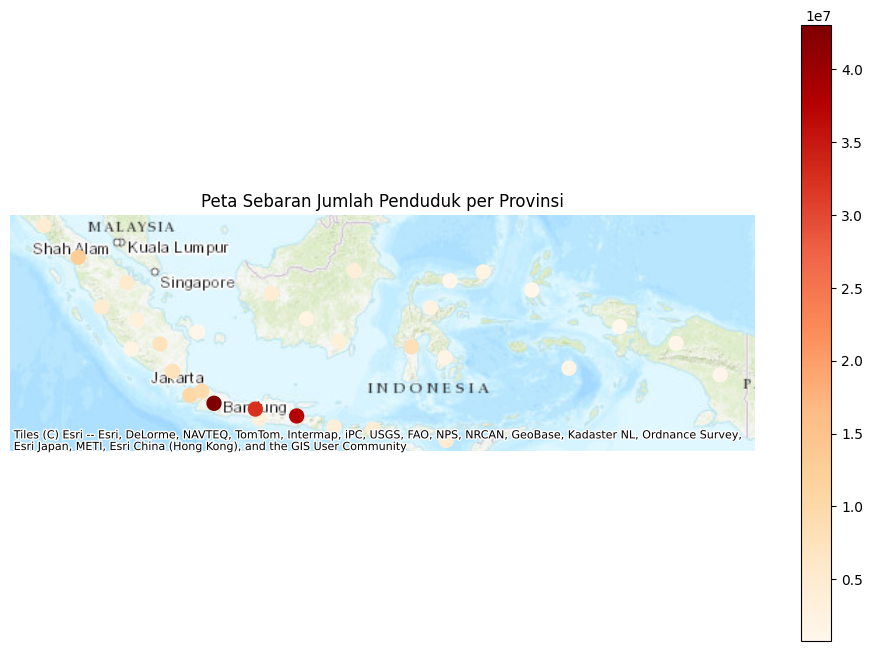

In [148]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = gdf.plot(
    column='jml_penduduk',
    cmap='OrRd',
    markersize=100,
    legend=True,
    ax=ax
)

# --- PILIH BASMAP YANG BENAR ---
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTerrain)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap)
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief)

ax.set_title("Peta Sebaran Jumlah Penduduk per Provinsi")
ax.set_axis_off()

plt.show()

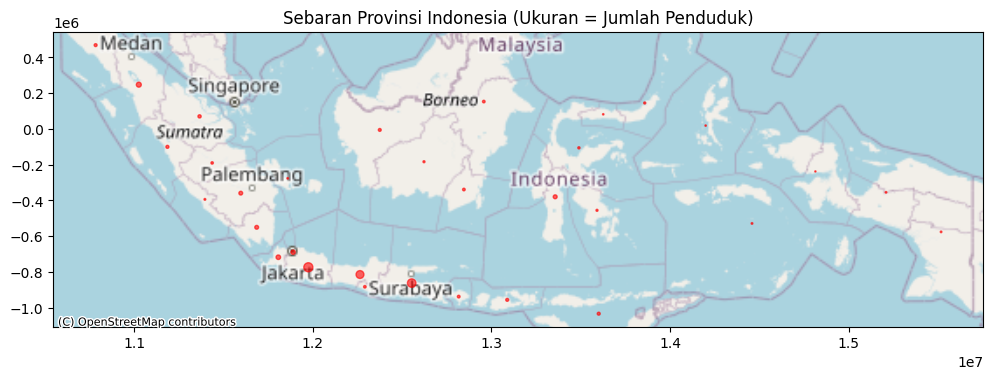

In [149]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np

# Jitter koordinat
np.random.seed(42)
long_peta = df['longitude'] + np.random.uniform(-0.05, 0.05, size=len(df))
lat_peta = df['latitude'] + np.random.uniform(-0.05, 0.05, size=len(df))

# GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(long_peta, lat_peta), crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)  # Web Mercator

# Plot peta
ax = gdf.plot(figsize=(12,8), color='red', alpha=0.6, markersize=gdf['jml_penduduk']/1e6)

# Tambahkan basemap modern
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Sebaran Provinsi Indonesia (Ukuran = Jumlah Penduduk)")
plt.show()

# **Visualisasi Peta dan Grafik Bar**

/tmp/ipython-input-2119863990.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2119863990.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



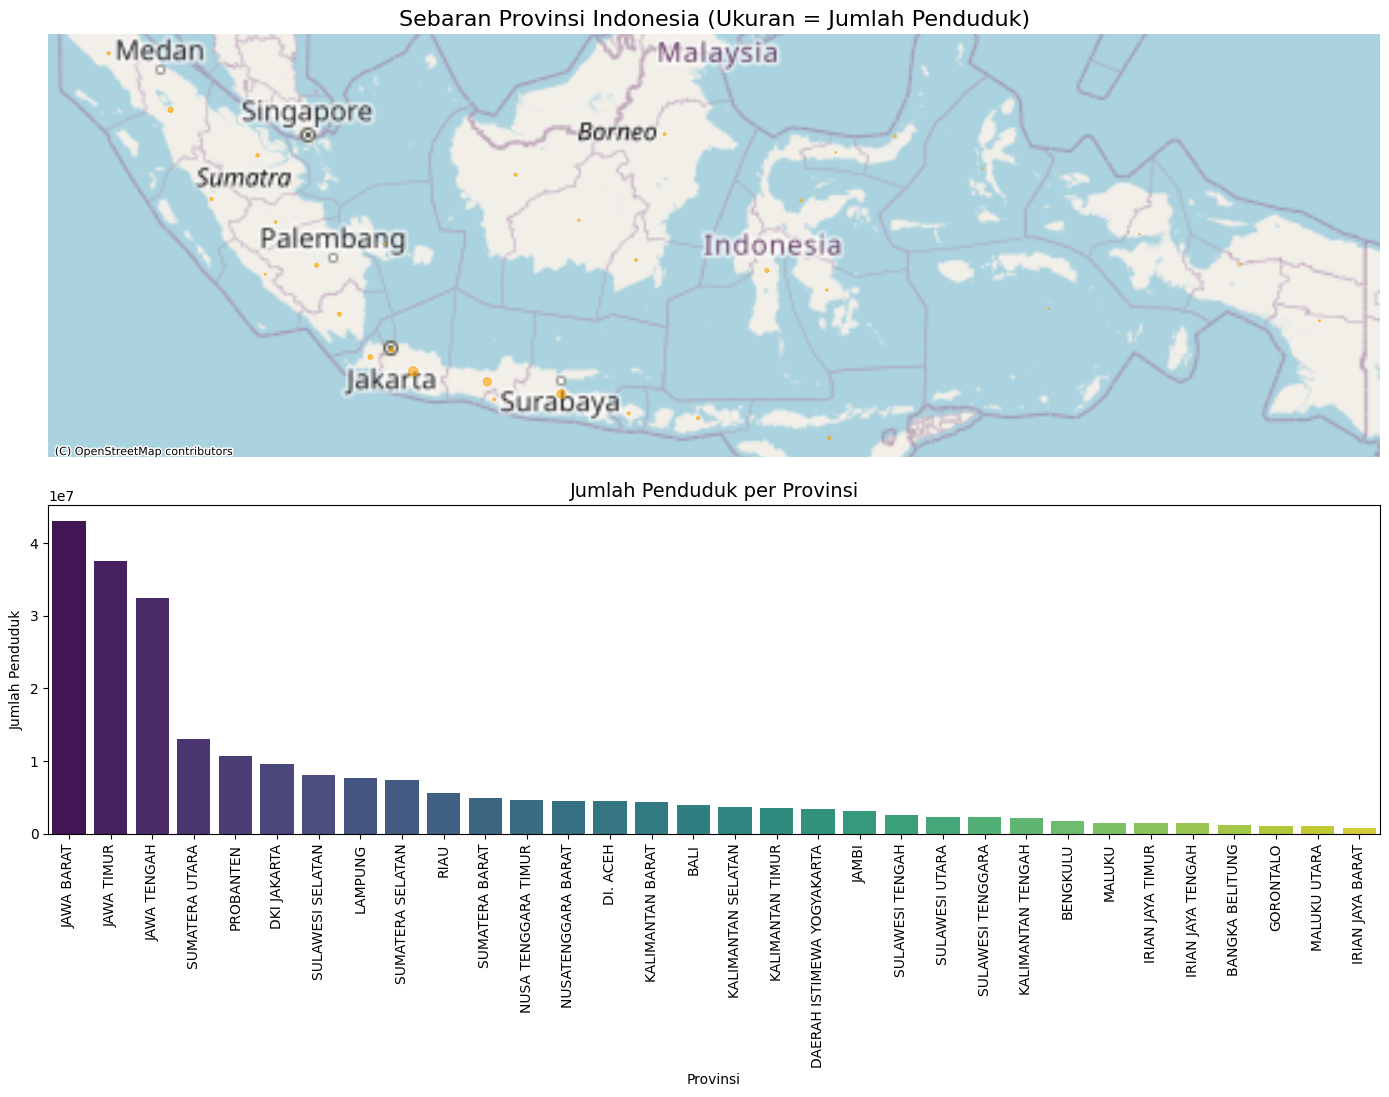

In [150]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import geopandas as gpd
import contextily as ctx
import numpy as np
import seaborn as sns

# Jitter koordinat supaya titik tidak tumpang tindih
np.random.seed(42)
long_peta = df['longitude'] + np.random.uniform(-0.05, 0.05, size=len(df))
lat_peta = df['latitude'] + np.random.uniform(-0.05, 0.05, size=len(df))

# Buat GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(long_peta, lat_peta), crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)

# Buat gridspec
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])

# --- Peta di atas ---
ax0 = fig.add_subplot(gs[0])
gdf.plot(ax=ax0, color='orange', alpha=0.6, markersize=gdf['jml_penduduk']/1e6)
ctx.add_basemap(ax0, source=ctx.providers.OpenStreetMap.Mapnik)
ax0.set_title("Sebaran Provinsi Indonesia (Ukuran = Jumlah Penduduk)", fontsize=16)
ax0.set_axis_off()

# --- Bar chart di bawah ---
ax1 = fig.add_subplot(gs[1])
df_sorted = df.sort_values(by='jml_penduduk', ascending=False)
sns.barplot(x='provinsi', y='jml_penduduk', data=df_sorted, palette='viridis', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_title("Jumlah Penduduk per Provinsi", fontsize=14)
ax1.set_ylabel("Jumlah Penduduk")
ax1.set_xlabel("Provinsi")

plt.tight_layout()
plt.show()


# **Boxplot Jumlah Penduduk Provinsi**

In [151]:
df.columns

Index(['provinsi', 'jml_penduduk', 'latitude', 'longitude'], dtype='object')

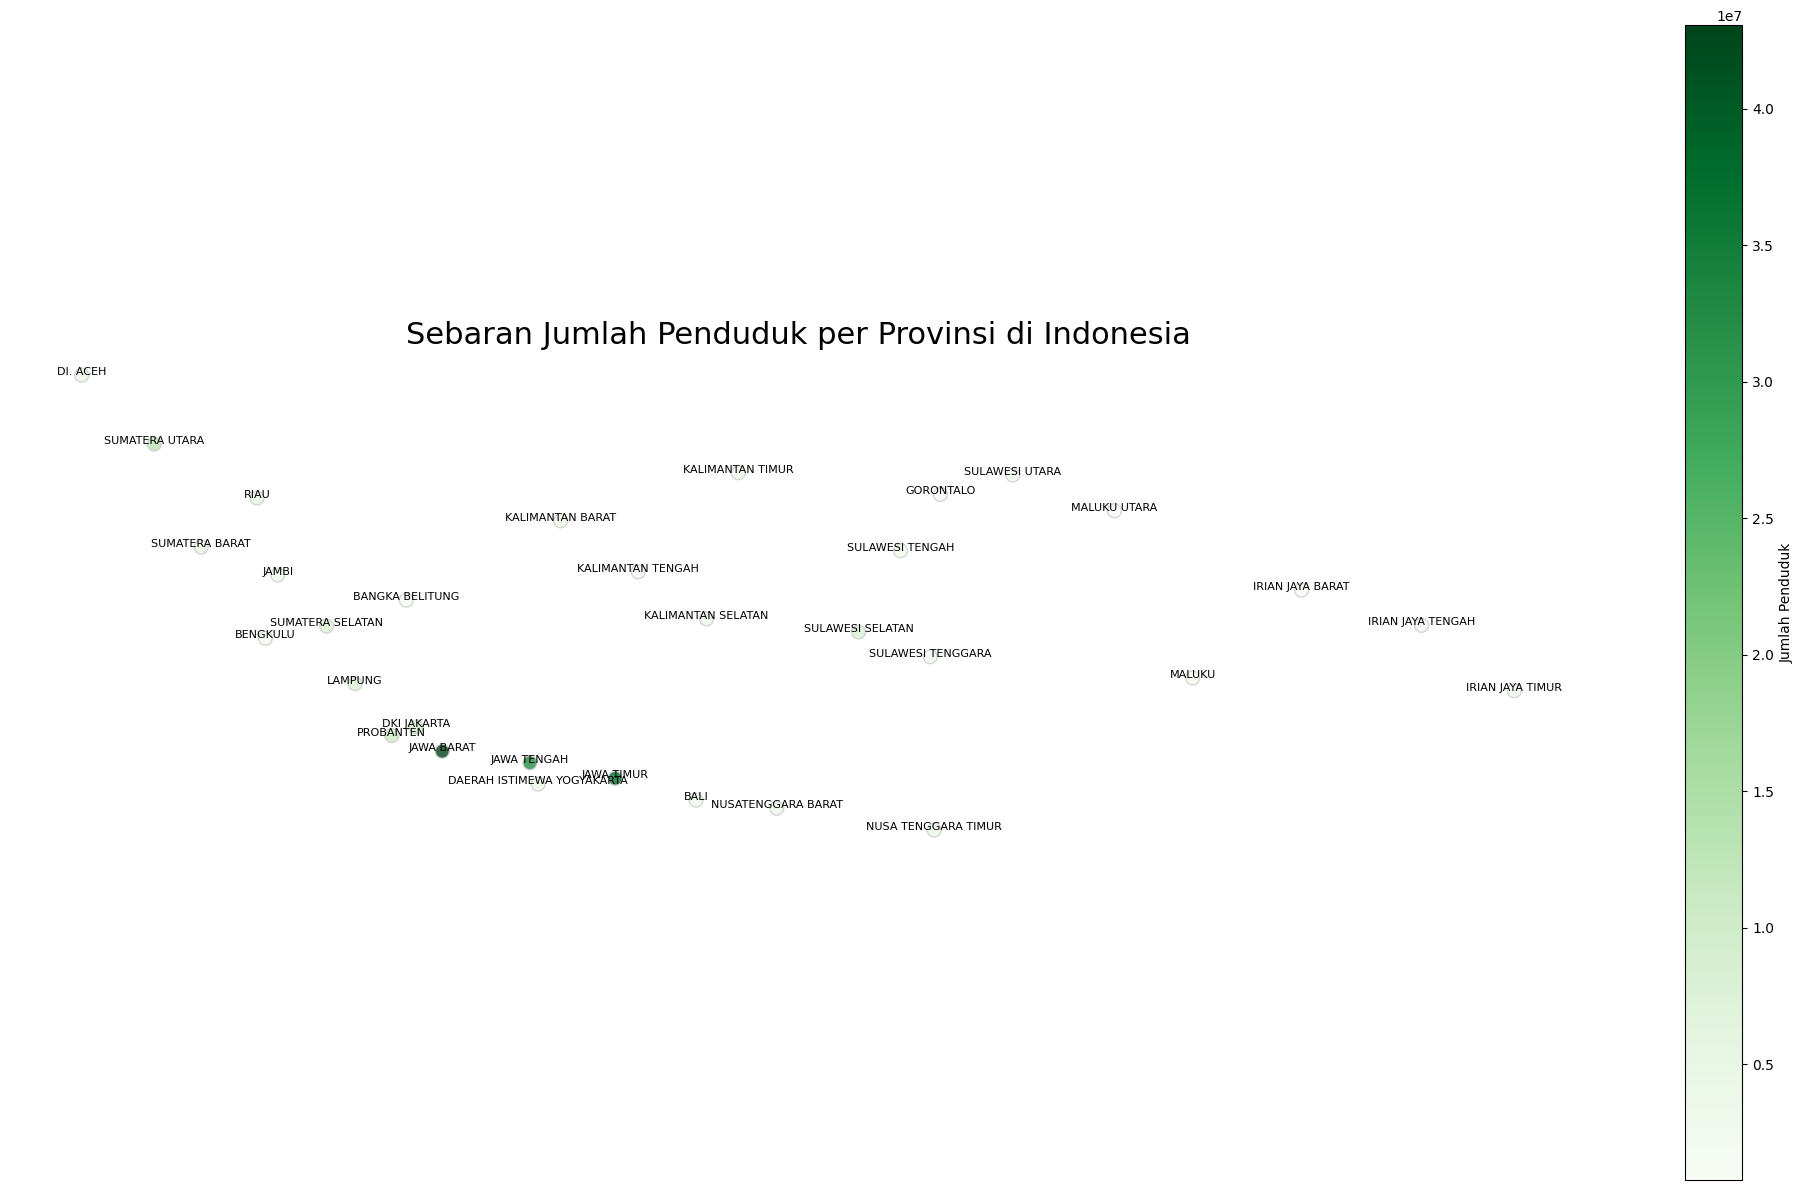

In [152]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Gunakan lat/lon sebagai centroid (tidak ada poligon)
gdf_skor = df.copy()
gdf_skor['geometry'] = gpd.points_from_xy(df['longitude'], df['latitude'])
gdf_skor = gpd.GeoDataFrame(gdf_skor, geometry='geometry', crs='EPSG:4326')

# Plot
fig, ax = plt.subplots(figsize=(20,12))
gdf_skor.plot(column='jml_penduduk', cmap='Greens', markersize=100,
              edgecolor='0.8', legend=True, ax=ax, alpha=0.8,
              legend_kwds={'label': "Jumlah Penduduk", 'orientation': "vertical"})

# Tambahkan label provinsi
for idx, row in gdf_skor.iterrows():
    plt.annotate(text=row['provinsi'],
                 xy=(row['geometry'].x, row['geometry'].y),
                 ha='center', fontsize=8, color='black')

ax.set_title("Sebaran Jumlah Penduduk per Provinsi di Indonesia", fontsize=22)
ax.axis('off')
plt.tight_layout()
plt.show()


# **Uji Normalitas**

In [153]:
from scipy.stats import shapiro

# Pilih hanya kolom numerik untuk uji normalitas
normalityTest_df = df[['jml_penduduk', 'latitude', 'longitude']]
normalityTest_df.info()

# Uji normalitas per kolom
for col in normalityTest_df.columns:
    stat, p = shapiro(normalityTest_df[col])
    print(f"\nKolom: {col}")
    print("Statistik: %.3f, P-value: %.3f" % (stat, p))
    if p > 0.05:
        print("→ Data berdistribusi normal (gagal tolak H0)")
    else:
        print("→ Data tidak berdistribusi normal (tolak H0)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   jml_penduduk  32 non-null     int64  
 1   latitude      32 non-null     float64
 2   longitude     32 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 900.0 bytes

Kolom: jml_penduduk
Statistik: 0.589, P-value: 0.000
→ Data tidak berdistribusi normal (tolak H0)

Kolom: latitude
Statistik: 0.975, P-value: 0.651
→ Data berdistribusi normal (gagal tolak H0)

Kolom: longitude
Statistik: 0.961, P-value: 0.301
→ Data berdistribusi normal (gagal tolak H0)


# **Analisis Matriks Korelasi (Spearman Correlation)**

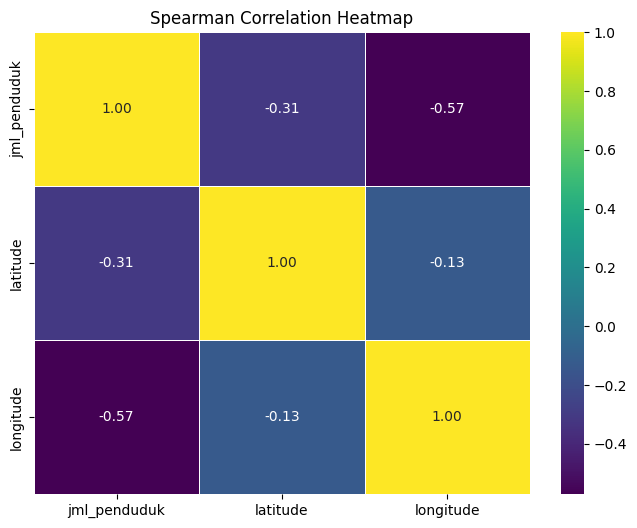

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih hanya kolom numerik
correlation_df = df[['jml_penduduk', 'latitude', 'longitude']]

# Hitung korelasi Spearman
correlation_matrix = correlation_df.corr(method='spearman')

# Visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()


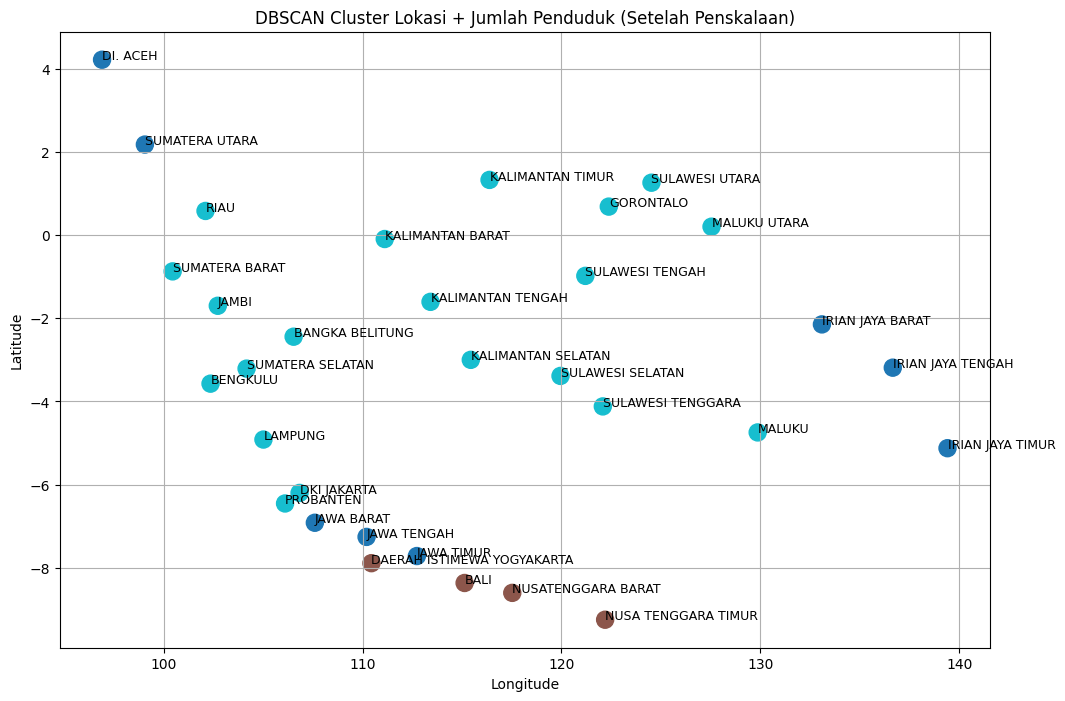

In [155]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Pilih Fitur
fitur_to_scale = ['latitude', 'longitude', 'jml_penduduk']
X = df[fitur_to_scale]

# 2. LAKUKAN PENSKALAAN (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X_scaled adalah array NumPy

# 3. Implementasi DBSCAN menggunakan data yang sudah diskalakan
# Parameter eps dan min_samples harus diuji coba pada data yang sudah diskalakan
db_comb = DBSCAN(eps=0.75, min_samples=4)
clusters_comb = db_comb.fit_predict(X_scaled)

# Tambahkan hasil cluster ke dataframe
df['cluster_comb'] = clusters_comb

# 4. Visualisasi (tetap menggunakan koordinat asli untuk plotting yang benar)
plt.figure(figsize=(12,8))
plt.scatter(df['longitude'], df['latitude'], c=df['cluster_comb'], cmap='tab10', s=150)
for i, prov in enumerate(df['provinsi']):
    plt.text(df['longitude'][i], df['latitude'][i], prov, fontsize=9)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Cluster Lokasi + Jumlah Penduduk (Setelah Penskalaan)")
plt.grid(True)
plt.show()

# **Analisis Korelasi Spesifik: Jumlah Penduduk vs Latitude**

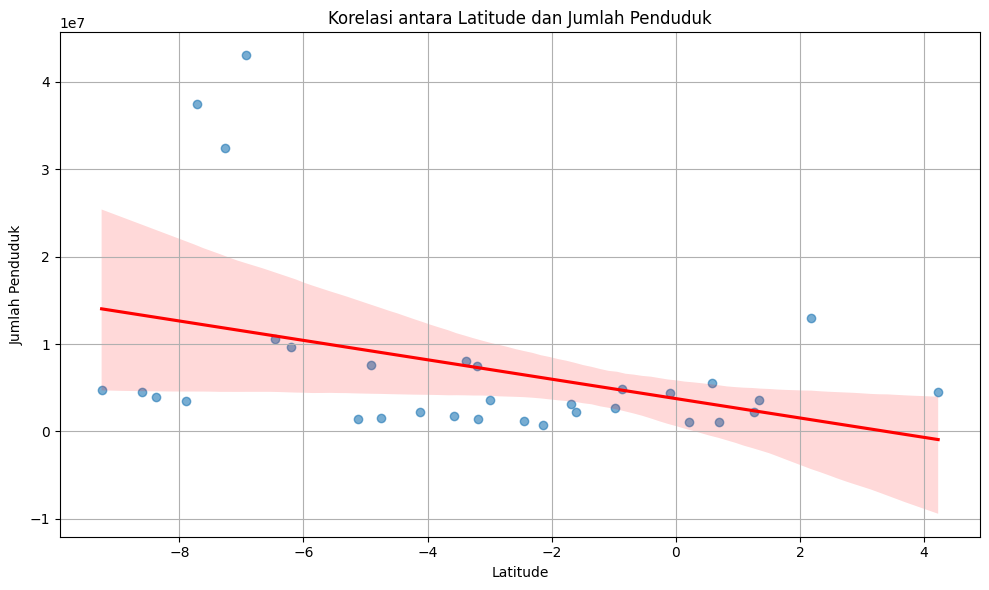

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(
    x="latitude",
    y="jml_penduduk",
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={"color": "red"}
)
plt.title("Korelasi antara Latitude dan Jumlah Penduduk")
plt.xlabel("Latitude")
plt.ylabel("Jumlah Penduduk")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Normalisasi Data**

### **Pemilihan Kolom untuk Normalisasi**

In [157]:
# Pilih hanya kolom numerik yang relevan untuk clustering
normalisasi_df = df[['jml_penduduk', 'latitude', 'longitude']]

# Cek info
normalisasi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   jml_penduduk  32 non-null     int64  
 1   latitude      32 non-null     float64
 2   longitude     32 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 900.0 bytes


### **Proses Normalisasi dengan RobustScaler**

In [158]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Simpan nama kolom
column_names = normalisasi_df.columns

# Inisialisasi RobustScaler
scaler = RobustScaler()

# Normalisasi
normalisasi_df_scaled = scaler.fit_transform(normalisasi_df)

# Kembalikan ke DataFrame
normalisasi_df_scaled = pd.DataFrame(normalisasi_df_scaled, columns=column_names)

# Tampilkan 5 baris pertama
normalisasi_df_scaled.head()

,jml_penduduk,latitude,longitude
0,-0.433546,-0.344637,1.617964
1,0.137270,-0.967456,0.273594
2,-0.503248,0.695477,0.571730
3,-0.282509,-0.164742,0.553277
4,-0.055757,-0.839622,-0.161426


# **Menentukan Parameter ε (epsilon) menggunakan K-Distance Graph**

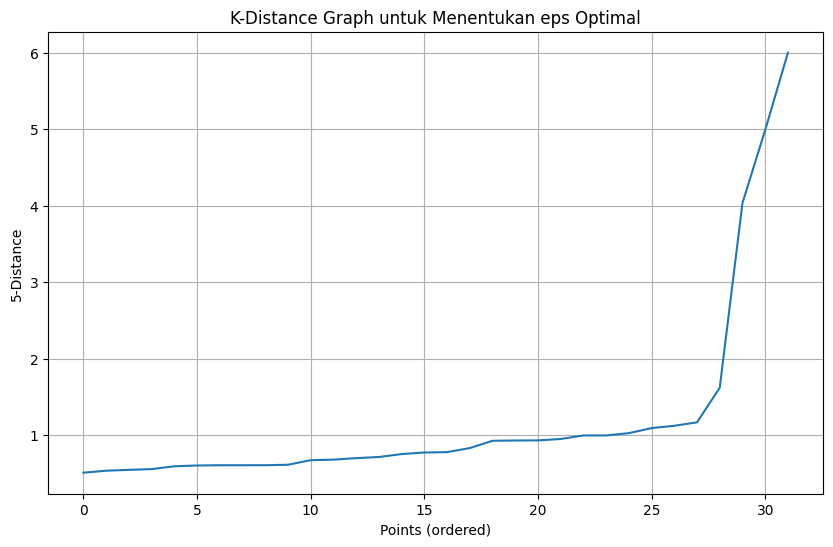

In [159]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Gunakan data hasil normalisasi
X = normalisasi_df_scaled.values

# Tentukan jumlah tetangga (min_samples biasanya 4-10)
k = 5

# Fit nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ambil jarak tetangga ke-k (k-distance)
k_distances = np.sort(distances[:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

# **Clustering dengan DBSCAN**

In [160]:
from sklearn.cluster import DBSCAN

# Misal dari K-Distance Graph didapat eps = 0.8, min_samples = 5
eps_value = 0.8
min_samples_value = 5

# Inisialisasi DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)

# Fit dan prediksi cluster
labels = dbscan.fit_predict(normalisasi_df_scaled.values)

# Tambahkan hasil cluster ke dataframe asli
df['Cluster_DBSCAN'] = labels

# Cek jumlah titik per cluster
print(df['Cluster_DBSCAN'].value_counts())

Cluster_DBSCAN
 0    22
-1    10
Name: count, dtype: int64


# **Evaluasi Kualitas Clustering menggunakan Silhouette Score**

In [161]:
# Hitung jumlah cluster unik (tanpa -1)
n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
print("Jumlah cluster (tidak termasuk noise):", n_clusters)


Jumlah cluster (tidak termasuk noise): 1


In [162]:
# eksperimen eps dan min_samples
from sklearn.cluster import DBSCAN

# Coba eps lebih kecil, min_samples lebih rendah
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels = dbscan.fit_predict(normalisasi_df_scaled.values)

df['Cluster_DBSCAN'] = labels

# Cek cluster
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Jumlah cluster (tidak termasuk noise):", n_clusters)
print(df['Cluster_DBSCAN'].value_counts())


Jumlah cluster (tidak termasuk noise): 4
Cluster_DBSCAN
 1    11
-1    10
 0     4
 2     4
 3     3
Name: count, dtype: int64


In [163]:
from sklearn.metrics import silhouette_score

# Hilangkan noise (label = -1)
mask = df['Cluster_DBSCAN'] != -1

# Hitung Silhouette Score
score = silhouette_score(normalisasi_df_scaled.values[mask], df['Cluster_DBSCAN'][mask])

print("Silhouette Score:", score)

Silhouette Score: 0.41123009117033454


# **Visualisasi Hasil Clustering dengan PCA (2D)**

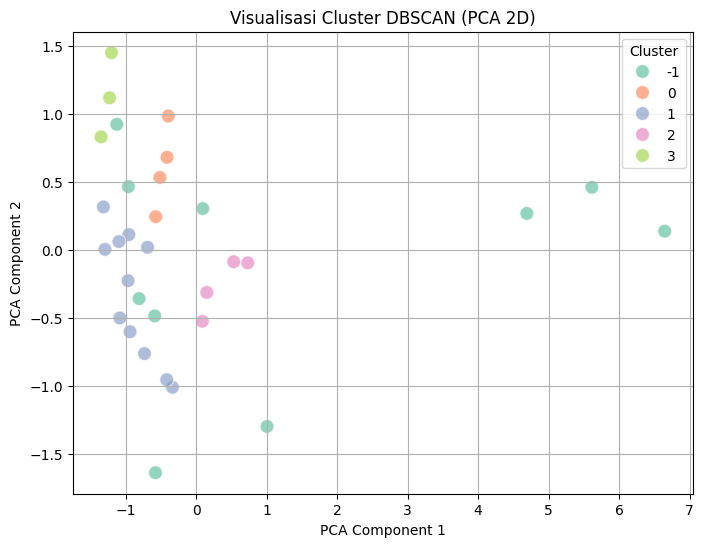

In [164]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(normalisasi_df_scaled.values)

# Plot scatter dengan warna cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=df['Cluster_DBSCAN'],
    palette="Set2",
    s=100,          # ukuran titik
    alpha=0.7        # transparansi
)
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# **Pengelompokan Kualitatif Cluster**

In [165]:
# Fungsi klasifikasi kualitatif
def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

# Terapkan ke DataFrame
df['Klasifikasi_DBSCAN'] = df['Cluster_DBSCAN'].apply(klasifikasi_db)

# Lihat jumlah tiap kategori
print(df['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Kurang    18
Noise     10
Baik       4
Name: count, dtype: int64


# **Analisis Lanjutan per Cluster (Cluster Summary)**

In [166]:
cluster_summary_db = df.groupby('Klasifikasi_DBSCAN').agg({
    'jml_penduduk': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Tampilkan summary
print("Summary Rata-rata per Cluster DBSCAN:\n")
print(cluster_summary_db)

Summary Rata-rata per Cluster DBSCAN:

  Klasifikasi_DBSCAN  jml_penduduk  latitude   longitude
0               Baik  4.133072e+06 -8.529600  116.324475
1             Kurang  3.785082e+06 -2.368978  114.997817
2              Noise  1.501398e+07 -2.649388  112.589881


# **Visualisasi Interaktif Persebaran Cluster (Plotly)**

In [168]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA

# Gunakan data numerik yang sudah dinormalisasi untuk PCA
X = normalisasi_df.values  # normalisasi_df = hasil normalisasi RobustScaler

# PCA 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

# Buat DataFrame untuk Plotly
df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = df["Klasifikasi_DBSCAN"].values
df_pca_db["Provinsi"] = df["provinsi"].values

# Plot interaktif dengan Plotly Express
fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="Provinsi",
    title="Persebaran Data Berdasarkan Klasifikasi Cluster DBSCAN",
    width=1200,
    height=800
)

fig.show()